<a href="https://colab.research.google.com/github/EMANFATIMA06/DATA-SCIENCE-ANALYTICS/blob/main/Task-03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

***Task 3: Customer Churn Prediction (Bank Customers)***

***Step 1: Import Libraries***

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import warnings
warnings.filterwarnings('ignore')

In [4]:
# Load the dataset
df = pd.read_csv('/content/Churn_Modelling.csv')

print(f'Shape: {df.shape}')
df.head()

Shape: (10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [5]:
# Check for missing values and data types
print('Dataset Info:')
df.info()
print('\nMissing Values:')
print(df.isnull().sum())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB

Missing Values:
RowNumber          0
CustomerId         0
Surname            0


In [6]:
# Statistical summary
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


***Step 3: Clean and Prepare the Dataset***

In [7]:
# Drop non-informative columns
df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1, inplace=True)

print('Remaining columns:', df.columns.tolist())

Remaining columns: ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']


***Step 4: Exploratory Data Analysis (EDA)***

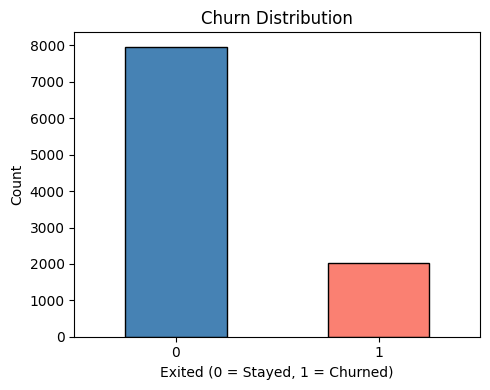

Overall churn rate: 20.4%


In [8]:
# Target variable: Exited (1 = churned, 0 = stayed)
plt.figure(figsize=(5, 4))
df['Exited'].value_counts().plot(kind='bar', color=['steelblue', 'salmon'], edgecolor='black')
plt.title('Churn Distribution')
plt.xlabel('Exited (0 = Stayed, 1 = Churned)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

churn_rate = df['Exited'].mean() * 100
print(f'Overall churn rate: {churn_rate:.1f}%')

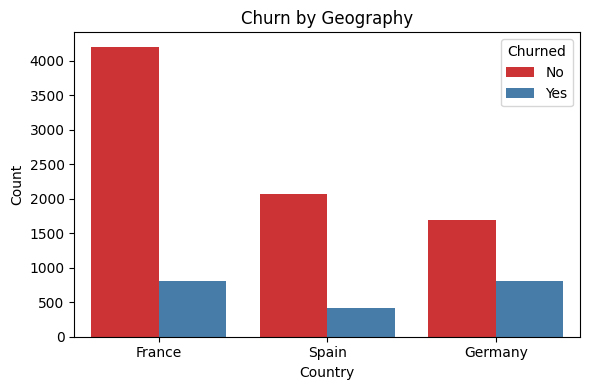

Observation: Germany has a notably higher churn rate compared to France and Spain.


In [9]:
# Churn by Geography
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Geography', hue='Exited', palette='Set1')
plt.title('Churn by Geography')
plt.xlabel('Country')
plt.ylabel('Count')
plt.legend(title='Churned', labels=['No', 'Yes'])
plt.tight_layout()
plt.show()

print('Observation: Germany has a notably higher churn rate compared to France and Spain.')

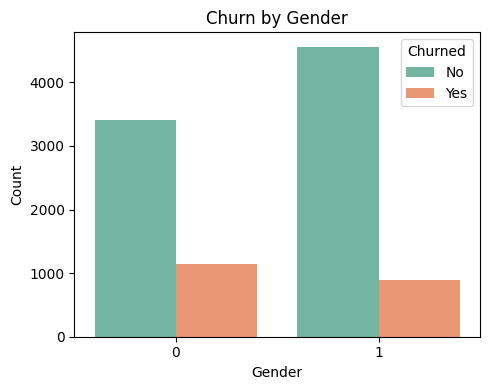

In [21]:
# Churn by Gender
plt.figure(figsize=(5, 4))
sns.countplot(data=df, x='Gender', hue='Exited', palette='Set2')
plt.title('Churn by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.legend(title='Churned', labels=['No', 'Yes'])
plt.tight_layout()
plt.show()

Observation: Female customers churn at a higher rate than male customers.

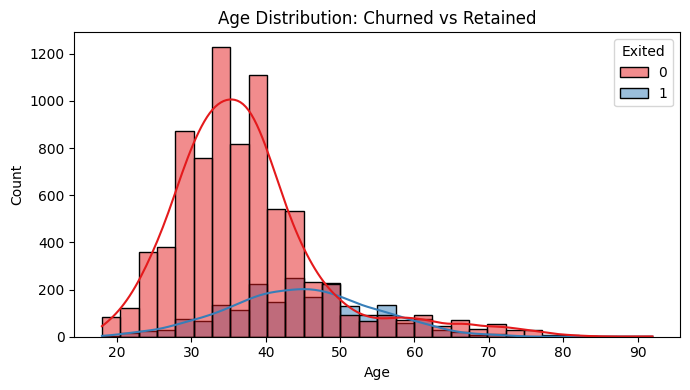

In [22]:
# Age distribution for churned vs non-churned
plt.figure(figsize=(7, 4))
sns.histplot(data=df, x='Age', hue='Exited', kde=True, palette='Set1', bins=30)
plt.title('Age Distribution: Churned vs Retained')
plt.xlabel('Age')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

Observation: Older customers (40-60) are more likely to churn.

***Step 5: Encode Categorical Features***

In [12]:
# Label encode Gender (Male=1, Female=0)
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])

# One-Hot Encode Geography (creates separate columns for each country)
df = pd.get_dummies(df, columns=['Geography'], drop_first=True)

print('Encoding complete. Columns now:')
print(df.columns.tolist())
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


***Step 6: Split Data and Train Model***

In [15]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Encode Gender
df['Gender'] = le.fit_transform(df['Gender'])  # Male=1, Female=0

# One-hot encode Geography (France, Germany, Spain)
df = pd.get_dummies(df, columns=['Geography'], drop_first=True)

print('Encoding done! Columns now:')
print(df.columns.tolist())

Encoding done! Columns now:
['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'Geography_Germany', 'Geography_Spain']


In [17]:
X = df.drop('Exited', axis=1)
y = df['Exited']

# Split into 80% train and 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature scaling — Random Forest doesn't need it, but it's good practice
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print('Training Sample', X_train.shape)
print('Testing Sample', X_test.shape)

Training Sample (8000, 11)
Testing Sample (2000, 11)


In [19]:
# Train a Random Forest Classifier
# Random Forest builds many decision trees and takes a majority vote
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print('Random Forest Accuracy:',accuracy_score(y_test, y_pred)*100)

Random Forest Accuracy: 86.65


***Step 7: Evaluate the Model***

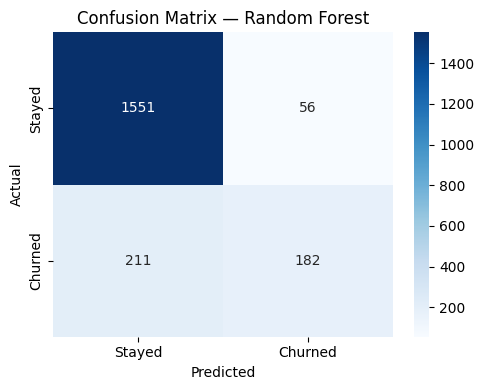


Classification Report:
              precision    recall  f1-score   support

      Stayed       0.88      0.97      0.92      1607
     Churned       0.76      0.46      0.58       393

    accuracy                           0.87      2000
   macro avg       0.82      0.71      0.75      2000
weighted avg       0.86      0.87      0.85      2000



In [20]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stayed', 'Churned'],
            yticklabels=['Stayed', 'Churned'])
plt.title('Confusion Matrix — Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['Stayed', 'Churned']))

Step 8: Conclusion

1. Churn Rate: Approximately 20% of customers in this dataset churned.
2. Key Drivers of Churn:
- Age — Older customers (40-60) are more likely to leave.
- Balance — Customers with higher balances sometimes churn more.
- Geography — Germany has a significantly higher churn rate.
- Gender — Female customers churn at a higher rate.
3. Model Performance: Random Forest delivered strong accuracy and is robust to imbalanced data.
4. Business Recommendation: The bank should focus retention efforts on older female customers in Germany with high account balances.